In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/aadityasanil/Desktop/Lab Testing Feb 19/Coevolutionary-Dynamics-Cryptic-Female-Choice/Running_Sims/CSV data March/run_v2_2026-04-06T17-43-01/kbuffer_v2_results_2026-04-06T17-43-01.csv")

In [3]:
print(df.columns)

Index(['MeanMale', 'MeanFemale', 'SDMale', 'SDFemale', 'cor', 'MeanCount',
       'SDCount', 'is', 'int', 'BMale', 'GMale', 'BFemale', 'GFemale',
       'BSperm', 'GSperm', 'GMF', 'GMS', 'GFS', 'a', 'MeanRSC', 'Generation',
       'MeanMates', 'population', 'males', 'females', 'offspring',
       'offspring_desired', 'offspring_realized', 'offspring_dropped', 'Rep',
       'TotalOffspringBorn'],
      dtype='object')


In [4]:
Fish = df[['MeanRSC','MeanMates','males','females','population','Generation', 'Rep']]
Fish.head(30)


,MeanRSC,MeanMates,males,females,population,Generation,Rep
0,3.888000,3.140,500.0,500.0,1000.0,1.0,1.0
1,3.908578,3.238,500.0,500.0,1000.0,2.0,1.0
2,3.946771,3.292,500.0,500.0,1000.0,3.0,1.0
3,3.940354,3.130,500.0,500.0,1000.0,4.0,1.0
4,3.881137,3.232,500.0,500.0,1000.0,5.0,1.0
5,3.881854,3.180,500.0,500.0,1000.0,6.0,1.0
6,3.773712,3.076,500.0,500.0,1000.0,7.0,1.0
7,3.683592,3.154,500.0,500.0,1000.0,8.0,1.0
8,3.621165,3.124,500.0,500.0,1000.0,9.0,1.0
9,3.582630,3.218,500.0,500.0,1000.0,10.0,1.0


<Axes: xlabel='MeanRSC', ylabel='offspring'>

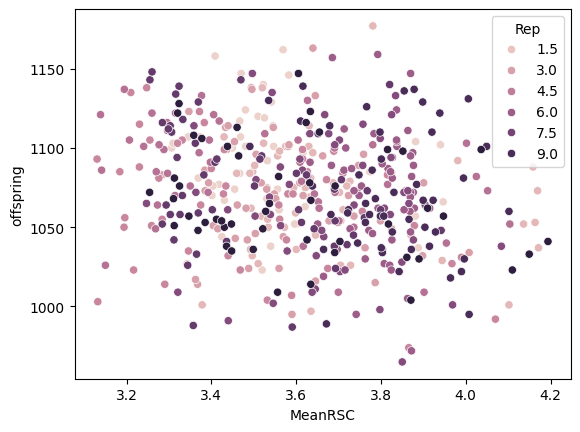

In [5]:

sns.scatterplot(data=df, x='MeanRSC', y='offspring', hue='Rep')


<Axes: xlabel='Generation', ylabel='offspring'>

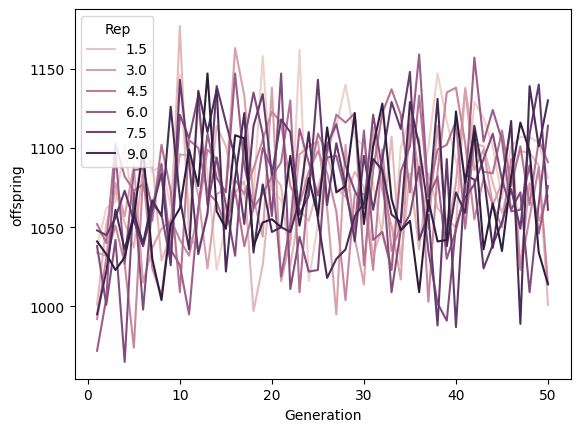

In [6]:

sns.lineplot(data=df, x='Generation', y='offspring', hue='Rep')


<Axes: xlabel='MeanMates', ylabel='MeanRSC'>

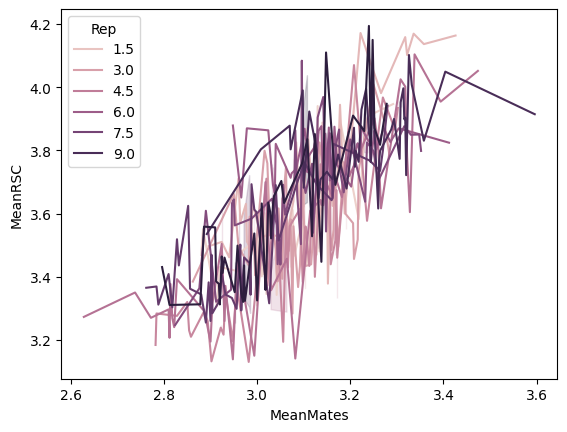

In [7]:
sns.lineplot(data=df, x='MeanMates', y='MeanRSC', hue='Rep')


In [8]:
correlation_value = df["MeanRSC"].corr(df["MeanMates"])
correlation_value2 = df["MeanRSC"].corr(df["offspring"])
print("Correlation between MeanRSC and MeanMates:", correlation_value)
print("Correlation between MeanRSC and Offspring:", correlation_value2)


Correlation between MeanRSC and MeanMates: 0.7550962799558487
Correlation between MeanRSC and Offspring: -0.21397105200879682


Correlation between MeanRSC and MeanMates per Replicate:


/var/folders/wz/d278rfq552s_spmdvg1220200000gn/T/ipykernel_49967/1853199143.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_df = df.groupby('Rep').apply(


,Rep,Correlation (RSC vs Mates)
0,1.0,0.681885
1,2.0,0.804122
2,3.0,0.411422
3,4.0,0.789981
4,5.0,0.838612
5,6.0,0.284625
6,7.0,0.676540
7,8.0,0.727177
8,9.0,0.501852
9,10.0,0.804567


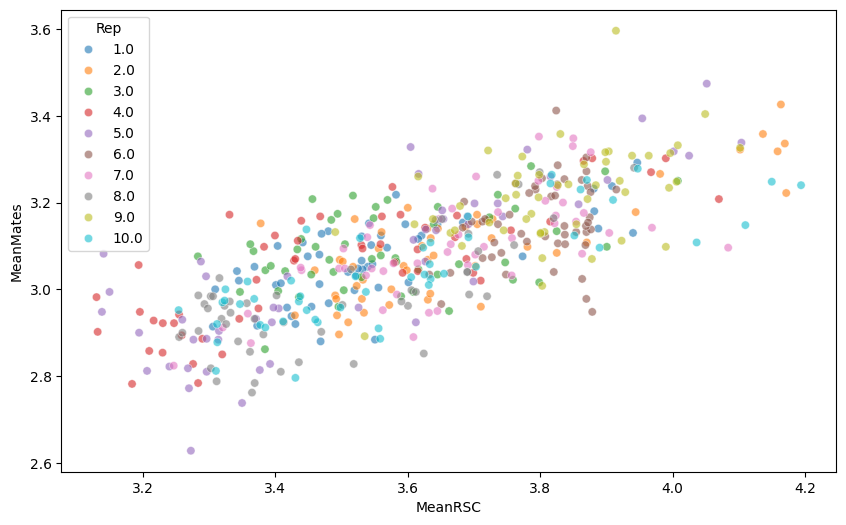

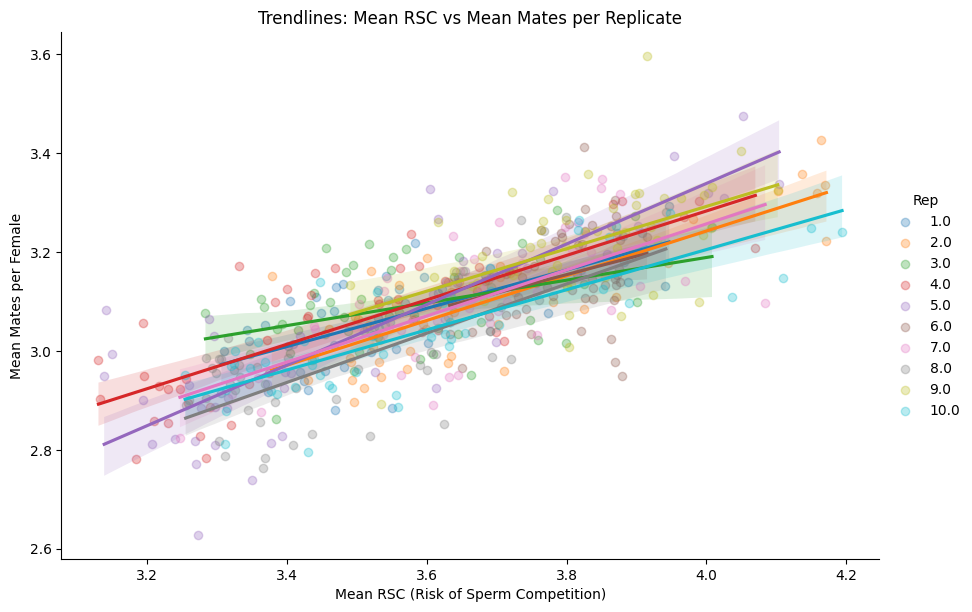

In [9]:
# Group by replicate and calculate the correlation between MeanRSC and MeanMates
correlation_df = df.groupby('Rep').apply(
    lambda g: g['MeanRSC'].corr(g['MeanMates'])
).reset_index(name='Correlation (RSC vs Mates)')

# Display the correlation table
print("Correlation between MeanRSC and MeanMates per Replicate:")
display(correlation_df)

# Plot the data to visually see the correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='MeanRSC', y='MeanMates', hue='Rep', palette='tab10', alpha=0.6)

# Overlay trendlines for each replicate using lmplot (optional, opens in a new figure)
sns.lmplot(data=df, x='MeanRSC', y='MeanMates', hue='Rep', palette='tab10', scatter_kws={'alpha': 0.3}, height=6, aspect=1.5)
plt.title("Trendlines: Mean RSC vs Mean Mates per Replicate")
plt.xlabel("Mean RSC (Risk of Sperm Competition)")
plt.ylabel("Mean Mates per Female")

plt.show()
